In [3]:
!python3 -m pip install cobra

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 957.4 kB/s  0:00:0045.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 3.2 MB/s  0:00:01m 3.0 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 764.3/764.3 kB 29.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━  4/11 [ruamel.yaml]  WARNING: The script depinfo is installed in '/Users/subramanians/Library/Python/3.9/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [cobra]━━━  8/11 [pydantic]


In [67]:
import cobra
from cobra.io import load_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
model = load_model("textbook")

In [13]:
for rxn in model.reactions:
    print(rxn.id, ":",rxn.name, ":", rxn.reaction)

ACALD : acetaldehyde dehydrogenase (acetylating) : acald_c + coa_c + nad_c <=> accoa_c + h_c + nadh_c
ACALDt : R acetaldehyde reversible - transport : acald_e <=> acald_c
ACKr : acetate kinase : ac_c + atp_c <=> actp_c + adp_c
ACONTa : aconitase (half-reaction A, Citrate hydro-lyase) : cit_c <=> acon_C_c + h2o_c
ACONTb : aconitase (half-reaction B, Isocitrate hydro-lyase) : acon_C_c + h2o_c <=> icit_c
ACt2r : R acetate reversible transport via proton - symport : ac_e + h_e <=> ac_c + h_c
ADK1 : adenylate kinase : amp_c + atp_c <=> 2.0 adp_c
AKGDH : 2-Oxogluterate dehydrogenase : akg_c + coa_c + nad_c --> co2_c + nadh_c + succoa_c
AKGt2r : R 2 oxoglutarate reversible transport via - symport : akg_e + h_e <=> akg_c + h_c
ALCD2x : alcohol dehydrogenase (ethanol) : etoh_c + nad_c <=> acald_c + h_c + nadh_c
ATPM : ATP maintenance requirement : atp_c + h2o_c --> adp_c + h_c + pi_c
ATPS4r : ATP synthase (four protons for one ATP) : adp_c + 4.0 h_e + pi_c <=> atp_c + h2o_c + 3.0 h_c
Biomass_Ec

In [4]:
print(model.objective)
model.reactions.EX_glc__D_e.lower_bound = -18.5
model.reactions.EX_o2_e.lower_bound = -1000
solution = model.optimize()
print("Growth rate:", solution.objective_value)

Maximize
1.0*Biomass_Ecoli_core - 1.0*Biomass_Ecoli_core_reverse_2cdba
Growth rate: 1.6530718511568214


In [5]:
print(solution.fluxes)

ACALD     0.000000e+00
ACALDt    0.000000e+00
ACKr      6.426433e-15
ACONTa    1.036570e+01
ACONTb    1.036570e+01
              ...     
TALA      2.997855e+00
THD2      0.000000e+00
TKT1      2.997855e+00
TKT2      2.401096e+00
TPI       1.356210e+01
Name: fluxes, Length: 95, dtype: float64


In [8]:
active_fluxes = solution.fluxes[abs(solution.fluxes) > 1e-6]

print(active_fluxes)

ACONTa                10.365697
ACONTb                10.365697
AKGDH                  8.582198
ATPM                   8.390000
ATPS4r                80.606869
Biomass_Ecoli_core     1.653072
CO2t                 -40.652701
CS                    10.365697
CYTBD                 77.483169
ENO                   26.839054
EX_co2_e              40.652701
EX_glc__D_e          -18.500000
EX_h_e                33.160621
EX_h2o_e              52.694337
EX_nh4_e              -9.013870
EX_o2_e              -38.741584
EX_pi_e               -6.081155
FBA                   13.562100
FUM                    8.582198
G6PDH2r                9.880769
GAPD                  29.312050
GLCpts                18.500000
GLNS                   0.422690
GLUDy                 -8.591180
GND                    9.880769
H2Ot                 -52.694337
ICDHyr                10.365697
MDH                    8.582198
NADH16                68.900971
NH4t                   9.013870
O2t                   38.741584
PDH     

In [10]:
model.reactions.EX_o2_e.lower_bound = 0
anaerobic_solution = model.optimize()

print("Anaerobic growth rate:",
      anaerobic_solution.objective_value)
print(anaerobic_solution.fluxes)

Anaerobic growth rate: 0.47056517108868
ACALD    -14.674917
ACALDt     0.000000
ACKr     -15.173198
ACONTa     0.507693
ACONTb     0.507693
            ...    
TALA      -0.084184
THD2       8.068357
TKT1      -0.084184
TKT2      -0.254058
TPI       18.031929
Name: fluxes, Length: 95, dtype: float64


# Example 1: Growth on alternate substrates

In [5]:
print(model)

e_coli_core


In [6]:
for rxn in model.exchanges:
    print(rxn.id)

EX_ac_e
EX_acald_e
EX_akg_e
EX_co2_e
EX_etoh_e
EX_for_e
EX_fru_e
EX_fum_e
EX_glc__D_e
EX_gln__L_e
EX_glu__L_e
EX_h_e
EX_h2o_e
EX_lac__D_e
EX_mal__L_e
EX_nh4_e
EX_o2_e
EX_pi_e
EX_pyr_e
EX_succ_e


In [18]:
model.reactions.EX_glc__D_e.lower_bound = 0
model.reactions.EX_succ_e.lower_bound = -20
model.reactions.EX_o2_e.lower_bound = -1000

In [19]:
solution = model.optimize()

print("Growth rate:", solution.objective_value)

Growth rate: 0.8401341768471441


In [24]:
substrates = {
    "acetate": "EX_ac_e",
    "acetaldehyde": "EX_acald_e",
    "2-oxoglutarate": "EX_akg_e",
    "ethanol": "EX_etoh_e",
    "D-fructose": "EX_fru_e",
    "fumarate": "EX_fum_e",
    "D-glucose": "EX_glc__D_e",
    "L-glutamine": "EX_gln__L_e",
    "L-glutamate": "EX_glu__L_e",
    "D-lactate": "EX_lac__D_e",
    "L-malate": "EX_mal__L_e",
    "pyruvate": "EX_pyr_e",
    "succinate": "EX_succ_e"
}

results = []

for substrate_name, exchange_id in substrates.items():

    #AEROBIC 
    with model:
        for ex in substrates.values():
            model.reactions.get_by_id(ex).lower_bound = 0    
        model.reactions.get_by_id(exchange_id).lower_bound = -20
        model.reactions.EX_o2_e.lower_bound = -1000
        aerobic_solution = model.optimize()
        aerobic_growth = aerobic_solution.objective_value

    #ANAEROBIC
    with model:
        for ex in substrates.values():
            model.reactions.get_by_id(ex).lower_bound = 0
        model.reactions.get_by_id(exchange_id).lower_bound = -20
        model.reactions.EX_o2_e.lower_bound = 0
        anaerobic_solution = model.optimize()
        anaerobic_growth = anaerobic_solution.objective_value

    results.append({
        "Substrate": substrate_name,
        "Aerobic": aerobic_growth,
        "Anaerobic": anaerobic_growth
    })
    
df = pd.DataFrame(results)
df = df.round(4)
print(df.to_string(index=False))

     Substrate  Aerobic  Anaerobic
       acetate   0.3893    -0.1098
  acetaldehyde   0.6073    -0.0000
2-oxoglutarate   1.0982    -0.0963
       ethanol   0.6996    -0.1098
    D-fructose   1.7906     0.5163
      fumarate   0.7865    -0.0116
     D-glucose   1.7906     0.5163
   L-glutamine   1.1636    -0.1098
   L-glutamate   1.2425    -0.1098
     D-lactate   0.7403    -0.0116
      L-malate   0.7865    -0.0116
      pyruvate   0.6221     0.0655
     succinate   0.8401    -0.1098


/Users/subramanians/Library/Python/3.9/lib/python/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


# Example 2: Production of cofactors and biomass precursors

In [47]:
#Maximum ATP Yield
model = load_model("textbook")
glc = model.reactions.EX_glc__D_e
glc.lower_bound = -1
glc.upper_bound = -1
model.objective = "ATPM"
model.reactions.ATPM.lower_bound = 0
solution = model.optimize()
print(solution.objective_value)

17.499999999999794


In [48]:
active = solution.fluxes[abs(solution.fluxes) > 1e-6]
print(active.sort_values(ascending=False))

ATPM           17.5
ATPS4r         13.5
CYTBD          12.0
NADH16         10.0
EX_co2_e        6.0
O2t             6.0
EX_h2o_e        6.0
NADTRHD         2.0
ACONTb          2.0
ACONTa          2.0
CS              2.0
ICDHyr          2.0
MDH             2.0
PDH             2.0
SUCDi           2.0
FUM             2.0
AKGDH           2.0
ENO             2.0
GAPD            2.0
PYK             1.0
PFK             1.0
TPI             1.0
FBA             1.0
PGI             1.0
GLCpts          1.0
EX_glc__D_e    -1.0
PGK            -2.0
PGM            -2.0
SUCOAS         -2.0
H2Ot           -6.0
EX_o2_e        -6.0
CO2t           -6.0
Name: fluxes, dtype: float64


In [49]:
#Maximum NADH Yield
model.reactions.ATPM.lower_bound = 0
model.reactions.ATPM.upper_bound = 0
from cobra import Reaction
nadh_drain = Reaction("NADH_drain")
nadh_drain.name = "NADH drain"
nadh_drain.add_metabolites({
    model.metabolites.nadh_c: -1,
    model.metabolites.nad_c: 1,
    model.metabolites.h_c: 1
})
model.add_reactions([nadh_drain])
model.objective = "NADH_drain"
solution = model.optimize()
print(solution.objective_value)

10.000000000000004


In [50]:
#Maximum NADPH Yield
model.reactions.EX_glc__D_e.lower_bound = -1
model.reactions.EX_glc__D_e.upper_bound = -1
nadph_drain = Reaction("NADPH_drain")
nadph_drain.add_metabolites({
    model.metabolites.nadph_c: -1,
    model.metabolites.nadp_c: 1,
    model.metabolites.h_c: 1
})
model.add_reactions([nadph_drain])
model.objective = "NADPH_drain"
solution = model.optimize()
print(solution.objective_value)

8.77777777777778


In [51]:
#for anerobic condition
results = []
# 1. ATP MAXIMUM YIELD 
model = load_model("textbook")
model.reactions.EX_glc__D_e.lower_bound = -1
model.reactions.EX_glc__D_e.upper_bound = -1
model.reactions.EX_o2_e.lower_bound = 0
model.reactions.EX_o2_e.upper_bound = 0
model.objective = "ATPM"
model.reactions.ATPM.lower_bound = 0
solution = model.optimize()
results.append({
    "Cofactor": "ATP",
    "Yield (mol/mol glc)": solution.objective_value,
    "Constraint": "H+ balancing"
})

# 2. NADH MAXIMUM YIELD 
model.reactions.ATPM.lower_bound = 0
model.reactions.ATPM.upper_bound = 0
nadh_drain = Reaction("NADH_drain")
nadh_drain.add_metabolites({
    model.metabolites.nadh_c: -1,
    model.metabolites.nad_c: 1,
    model.metabolites.h_c: 1
})
model.add_reactions([nadh_drain])
model.objective = "NADH_drain"
solution = model.optimize()
results.append({
    "Cofactor": "NADH",
    "Yield (mol/mol glc)": solution.objective_value,
    "Constraint": "Energy"
})

# 3. NADPH MAXIMUM YIELD 
nadph_drain = Reaction("NADPH_drain")
nadph_drain.add_metabolites({
    model.metabolites.nadph_c: -1,
    model.metabolites.nadp_c: 1,
    model.metabolites.h_c: 1
})
model.add_reactions([nadph_drain])
model.objective = "NADPH_drain"
solution = model.optimize()
results.append({
    "Cofactor": "NADPH",
    "Yield (mol/mol glc)": solution.objective_value,
    "Constraint": "Energy"
})

df = pd.DataFrame(results)
df = df.round(4)
print(df.to_string(index=False))

Cofactor  Yield (mol/mol glc)   Constraint
     ATP                 2.75 H+ balancing
    NADH                 6.00       Energy
   NADPH                 4.00       Energy


In [54]:
model = load_model("textbook")
model.reactions.EX_glc__D_e.lower_bound = -1
model.reactions.EX_glc__D_e.upper_bound = -1
model.reactions.ATPM.lower_bound = 0

# PRECURSOR METABOLITES
precursors = {
    "3pg": "3pg_c",
    "pep": "pep_c",
    "pyr": "pyr_c",
    "oaa": "oaa_c",
    "g6p": "g6p_c",
    "f6p": "f6p_c",
    "r5p": "r5p_c",
    "e4p": "e4p_c",
    "g3p": "g3p_c",
    "accoa": "accoa_c",
    "akg": "akg_c",
    "succoa": "succoa_c"
}

results = []
for name, met_id in precursors.items():
    with model:
        met = model.metabolites.get_by_id(met_id)
        if name == "accoa":
            drain = Reaction("DM_accoa")
            drain.add_metabolites({
                model.metabolites.accoa_c: -1,
                model.metabolites.coa_c: 1
            })
            model.add_reactions([drain])
        elif name == "succoa":
            drain = Reaction("DM_succoa")
            drain.add_metabolites({
                model.metabolites.succoa_c: -1,
                model.metabolites.coa_c: 1
            })
            model.add_reactions([drain])
        else:
            drain = model.add_boundary(
                met,
                type="demand"
            )
        model.objective = drain
        solution = model.optimize()
        results.append({
            "Precursor": name,
            "Yield":
                solution.objective_value
        })
        
df = pd.DataFrame(results)
df = df.round(4)
print(df.to_string(index=False))

Precursor  Yield
      3pg 2.0000
      pep 2.0000
      pyr 2.0000
      oaa 2.0000
      g6p 0.8916
      f6p 0.8916
      r5p 1.0571
      e4p 1.2982
      g3p 1.6818
    accoa 2.0000
      akg 1.0000
   succoa 1.6400


# Example 3: Alternate optimal solutions

In [64]:
#FVA
from cobra.flux_analysis import flux_variability_analysis
model = load_model("textbook")
model.reactions.EX_glc__D_e.lower_bound = 0
model.reactions.EX_succ_e.lower_bound = -20
model.reactions.EX_o2_e.lower_bound = -1000
fva_result = flux_variability_analysis(
    model,
    reaction_list=["ME1"],
    fraction_of_optimum=1.0
)
print(fva_result)

     minimum   maximum
ME1      0.0  6.492425


In [65]:
fva_all = flux_variability_analysis(
    model,
    fraction_of_optimum=1.0
)
variable = fva_all[
    abs(fva_all["maximum"]
        - fva_all["minimum"]) > 1e-6
]
print(variable)

           minimum      maximum
FRD7      0.000000   972.768779
MDH      13.564992    20.057417
ME1       0.000000     6.492425
ME2       7.173804    13.666228
NADTRHD   0.000000     6.492425
PPCK      3.926283    10.418708
PYK       0.000000     6.492425
SUCDi    27.231221  1000.000000


# Example 4: Robustness analysis

/Users/subramanians/Library/Python/3.9/lib/python/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


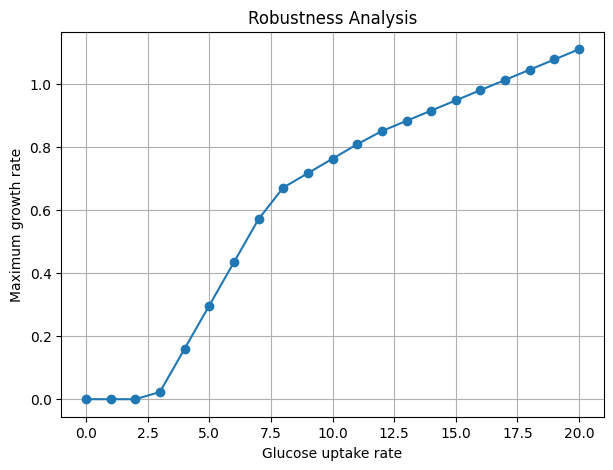

In [68]:
#Growth rate vs glucose uptake
model = load_model("textbook")
model.reactions.EX_o2_e.lower_bound = -17
model.reactions.EX_o2_e.upper_bound = -17

growth_rates = []
glucose_values = range(21)
for i in glucose_values:
    with model:
        # Fix glucose uptake
        model.reactions.EX_glc__D_e.lower_bound = -i
        model.reactions.EX_glc__D_e.upper_bound = -i
        solution = model.optimize()
        growth_rates.append(
            solution.objective_value
        )
plt.figure(figsize=(7,5))
plt.plot(
    glucose_values,
    growth_rates,
    marker='o'
)
plt.xlabel(
    "Glucose uptake rate"
)
plt.ylabel(
    "Maximum growth rate"
)
plt.title(
    "Robustness Analysis"
)
plt.grid(True)
plt.show()

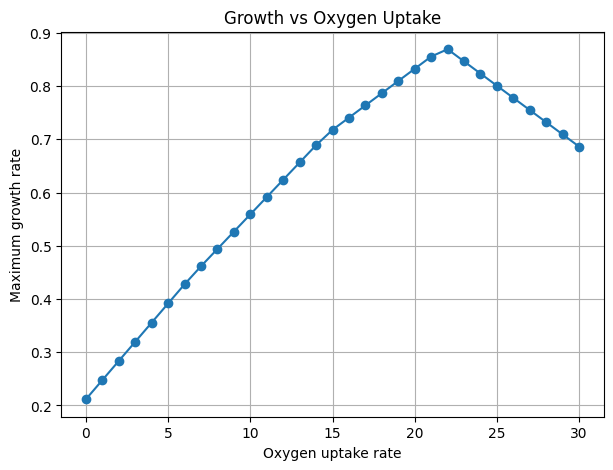

In [70]:
# Growth vs Oxygen Uptake
model = load_model("textbook")
model.reactions.EX_glc__D_e.lower_bound = -10
model.reactions.EX_glc__D_e.upper_bound = -10

growth_rates = []
oxygen_values = range(31)
for i in oxygen_values:
    with model:
        model.reactions.EX_o2_e.lower_bound = -i
        model.reactions.EX_o2_e.upper_bound = -i
        solution = model.optimize()
        growth_rates.append(
            solution.objective_value
        )
plt.figure(figsize=(7,5))
plt.plot(
    oxygen_values,
    growth_rates,
    marker='o'
)
plt.xlabel(
    "Oxygen uptake rate"
)
plt.ylabel(
    "Maximum growth rate"
)
plt.title(
    "Growth vs Oxygen Uptake"
)
plt.grid(True)
plt.show()

# Example 5: Phenotypic phase plane analysis

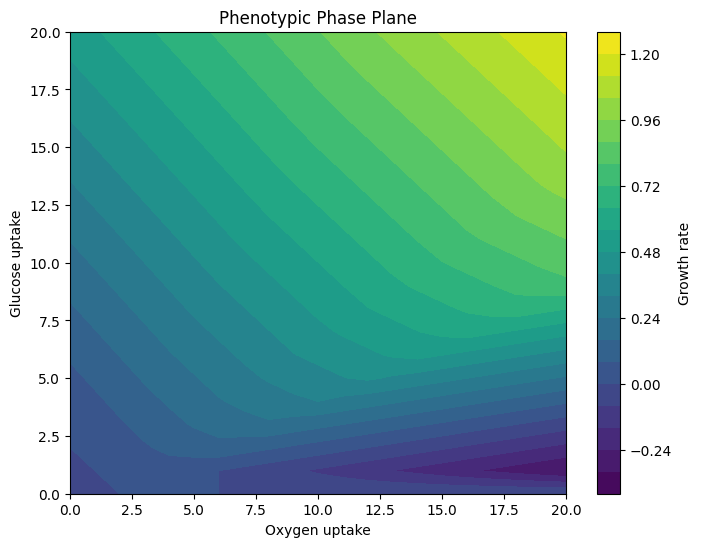

In [72]:
model = load_model("textbook")
glucose_range = range(21)
oxygen_range = range(21)
growth = np.zeros(
    (len(glucose_range),
     len(oxygen_range))
)
for i, glc in enumerate(glucose_range):
    for j, o2 in enumerate(oxygen_range):
        with model:
            model.reactions.EX_glc__D_e.lower_bound = -glc
            model.reactions.EX_glc__D_e.upper_bound = -glc
            model.reactions.EX_o2_e.lower_bound = -o2
            model.reactions.EX_o2_e.upper_bound = -o2
            solution = model.optimize()
            growth[i, j] = (
                solution.objective_value
            )

# Contour plot
X, Y = np.meshgrid(
    oxygen_range,
    glucose_range
)
plt.figure(figsize=(8,6))
contours = plt.contourf(
    X,
    Y,
    growth,
    levels=20
)
plt.colorbar(
    contours,
    label="Growth rate"
)
plt.xlabel(
    "Oxygen uptake"
)
plt.ylabel(
    "Glucose uptake"
)
plt.title(
    "Phenotypic Phase Plane"
)
plt.show()

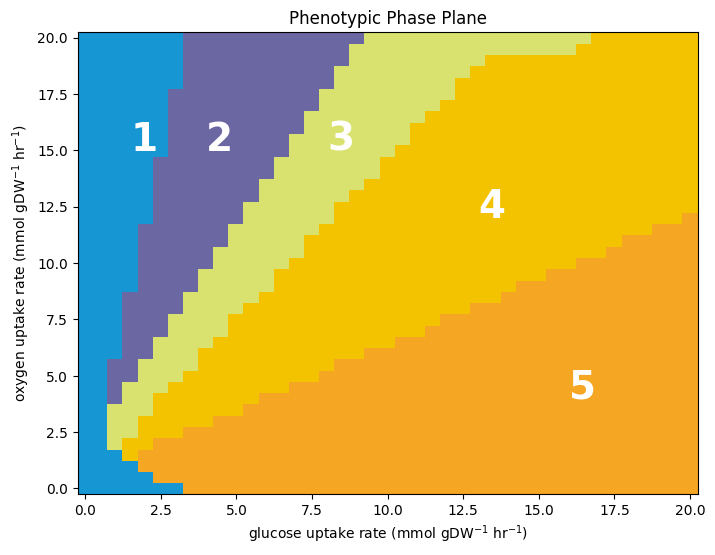

In [75]:
from matplotlib.colors import ListedColormap
model = load_model("textbook")
glucose_range = np.linspace(0,20,41)
oxygen_range = np.linspace(0,20,41)
phases = np.zeros(
    (len(oxygen_range),
     len(glucose_range))
)
for i, o2 in enumerate(oxygen_range):
    for j, glc in enumerate(glucose_range):
        with model:
            model.reactions.EX_glc__D_e.lower_bound = -glc
            model.reactions.EX_glc__D_e.upper_bound = -glc
            model.reactions.EX_o2_e.lower_bound = -o2
            model.reactions.EX_o2_e.upper_bound = -o2
            solution = model.optimize()
            growth = solution.objective_value
            acetate = max(
                0,
                solution.fluxes["EX_ac_e"]
            )
            formate = max(
                0,
                solution.fluxes["EX_for_e"]
            )
            ethanol = max(
                0,
                solution.fluxes["EX_etoh_e"]
            )
            if growth < 1e-6:
                phase = 1
            elif acetate < 1e-6:
                phase = 2
            elif acetate > 1e-6 and formate < 1e-6:
                phase = 3
            elif formate > 1e-6 and ethanol < 1e-6:
                phase = 4
            else:
                phase = 5
            phases[i,j] = phase

colors = [
    "#1696d2",  # phase 1
    "#6b67a3",  # phase 2
    "#d9e26f",  # phase 3
    "#f3c300",  # phase 4
    "#f5a623"   # phase 5
]
cmap = ListedColormap(colors)
# PLOT
plt.figure(figsize=(8,6))
plt.pcolor(
    glucose_range,
    oxygen_range,
    phases,
    cmap=cmap,
    shading='auto'
)
plt.xlabel(
    "glucose uptake rate (mmol gDW$^{-1}$ hr$^{-1}$)"
)
plt.ylabel(
    "oxygen uptake rate (mmol gDW$^{-1}$ hr$^{-1}$)"
)
plt.text(1.5,15,"1",
         fontsize=28,
         color="white",
         weight="bold")
plt.text(4,15,"2",
         fontsize=28,
         color="white",
         weight="bold")
plt.text(8,15,"3",
         fontsize=28,
         color="white",
         weight="bold")
plt.text(13,12,"4",
         fontsize=28,
         color="white",
         weight="bold")
plt.text(16,4,"5",
         fontsize=28,
         color="white",
         weight="bold")
plt.title(
    "Phenotypic Phase Plane"
)
plt.show()

# Example 6: Simulating gene knockouts

In [76]:
model = load_model("textbook")
print(len(model.genes))
for gene in model.genes[:10]:
    print(gene.id)

137
b1241
b0351
s0001
b3115
b1849
b2296
b1276
b0118
b0474
b0116


In [77]:
gene = model.genes.get_by_id("b2779")
print(gene)
print(gene.reactions)

b2779
frozenset({<Reaction ENO at 0x12bf173a0>})


In [78]:
with model:
    gene.knock_out()
    solution = model.optimize()
    print(
        "Growth after knockout:",
        solution.objective_value
    )

Growth after knockout: 0.0


In [80]:
#Compare Wild Type vs Knockout
model = load_model("textbook")
wt_solution = model.optimize()
print(
    "Wild-type growth:",
    wt_solution.objective_value
)
with model:
    model.genes.b2779.knock_out()
    ko_solution = model.optimize()
    print(
        "Knockout growth:",
        ko_solution.objective_value
    )
ratio = (
    ko_solution.objective_value
    /
    wt_solution.objective_value
)
print(ratio)

Wild-type growth: 0.8739215069684295
Knockout growth: -5.017867364478666e-16
-5.74178267094637e-16


In [81]:
from cobra.flux_analysis import single_gene_deletion
deletion_results = single_gene_deletion(model)
print(deletion_results.head())

       ids    growth   status
0  {b0116}  0.782351  optimal
1  {b2283}  0.211663  optimal
2  {b3731}  0.374230  optimal
3  {b1241}  0.873922  optimal
4  {b2464}  0.873922  optimal


In [82]:
essential = deletion_results[
    deletion_results["growth"] < 1e-6
]
print(essential)

        ids        growth   status
24  {b1779} -4.323368e-17  optimal
54  {b1136}  8.804436e-17  optimal
80  {b2926}  2.794699e-17  optimal
87  {b2779} -9.604957e-16  optimal
98  {b0720}  5.694389e-15  optimal


              ids        growth   status
0  {b1723, b2914}  8.739215e-01  optimal
1  {b2278, b1854}  2.116629e-01  optimal
2  {b2276, b2417}  2.116629e-01  optimal
3  {b1241, b3737}  3.742299e-01  optimal
4  {b3236, b2926}  1.774069e-15  optimal


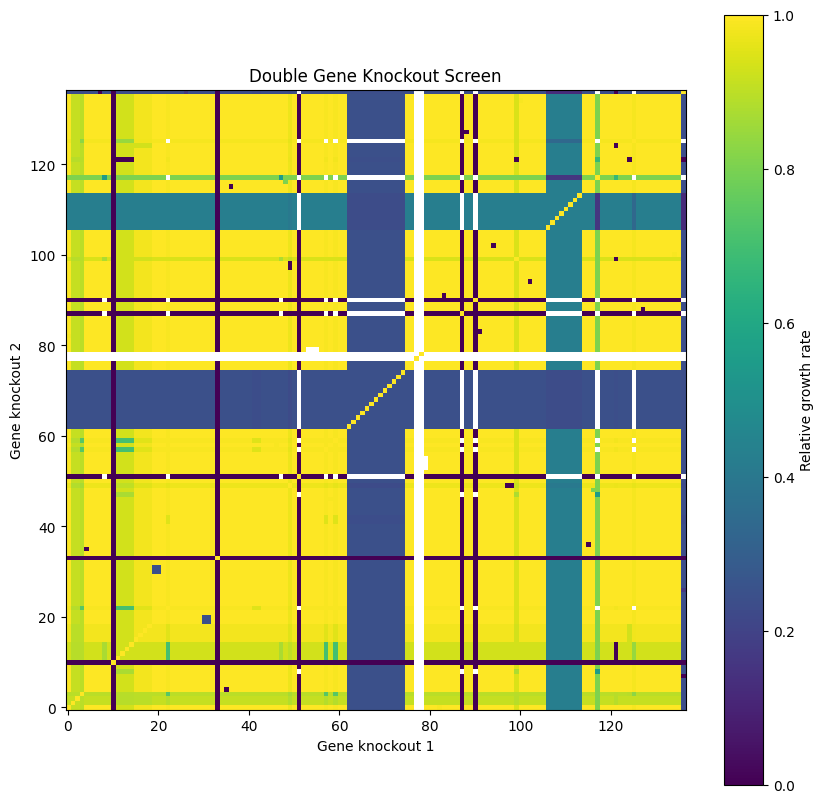

In [86]:
model = load_model("textbook")
from cobra.flux_analysis import double_gene_deletion
results = double_gene_deletion(model)
print(results.head())
genes = sorted(
    [g.id for g in model.genes]
)
n = len(genes)
matrix = np.ones((n,n))
wt_growth = model.optimize().objective_value
for _, row in results.iterrows():
    gene_pair = list(row["ids"])
    if len(gene_pair) != 2:
        continue
    growth = row["growth"]
    relative_growth = growth / wt_growth
    g1 = gene_pair[0]
    g2 = gene_pair[1]
    i = genes.index(g1)
    j = genes.index(g2)
    matrix[i,j] = relative_growth
    matrix[j,i] = relative_growth
plt.figure(figsize=(10,10))
plt.imshow(
    matrix,
    origin="lower",
    cmap="viridis"
)
plt.colorbar(
    label="Relative growth rate"
)
plt.xlabel("Gene knockout 1")
plt.ylabel("Gene knockout 2")
plt.title(
    "Double Gene Knockout Screen"
)
plt.show()

# Example 7: which genes are essential for which biomass precursor?

Analyzing: 3pg
Analyzing: pep


/Users/subramanians/Library/Python/3.9/lib/python/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Analyzing: pyr
Analyzing: oaa
Analyzing: g6p
Analyzing: f6p
Analyzing: r5p
Analyzing: e4p
Analyzing: g3p
Analyzing: accoa
Analyzing: akg
Analyzing: succoa


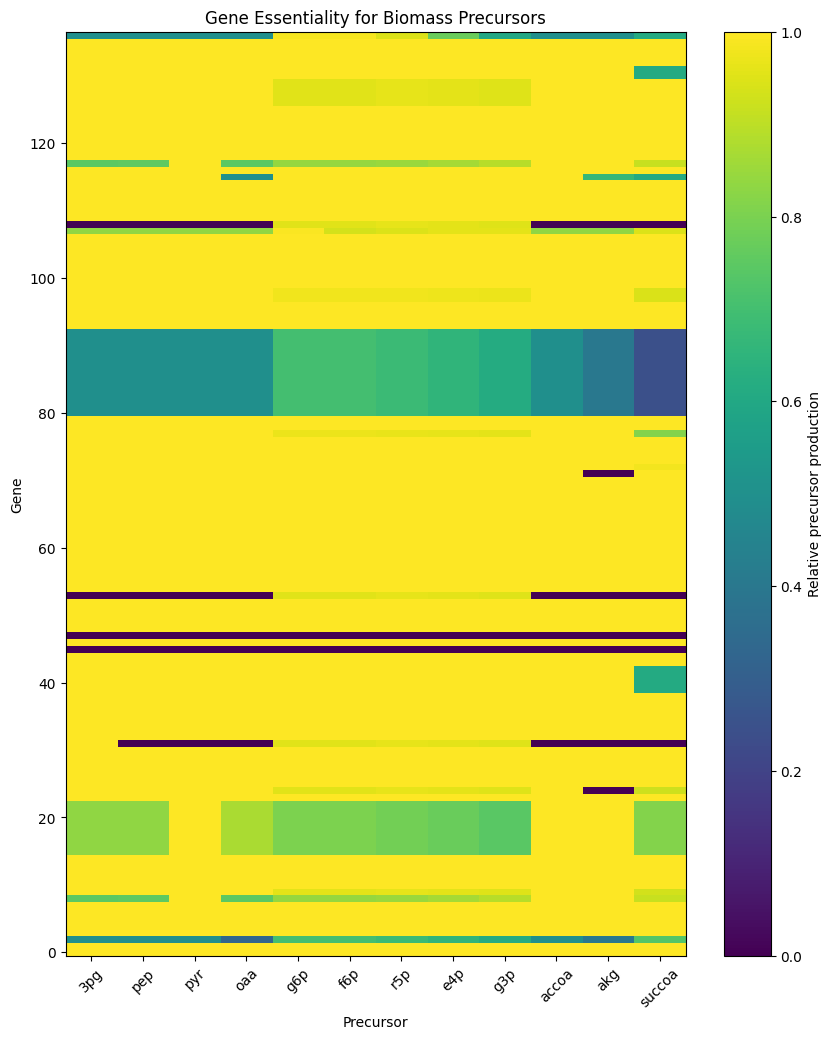

In [87]:
model = load_model("textbook")
precursors = {
    "3pg": "3pg_c",
    "pep": "pep_c",
    "pyr": "pyr_c",
    "oaa": "oaa_c",
    "g6p": "g6p_c",
    "f6p": "f6p_c",
    "r5p": "r5p_c",
    "e4p": "e4p_c",
    "g3p": "g3p_c",
    "accoa": "accoa_c",
    "akg": "akg_c",
    "succoa": "succoa_c"
}
genes = [g.id for g in model.genes]
matrix = pd.DataFrame(
    index=genes,
    columns=precursors.keys()
)

for precursor_name, met_id in precursors.items():
    print("Analyzing:", precursor_name)
    for gene_id in genes:
        with model:
            model.reactions.EX_glc__D_e.lower_bound = -1
            model.reactions.EX_glc__D_e.upper_bound = -1
            model.reactions.ATPM.lower_bound = 0
            met = model.metabolites.get_by_id(met_id)
            if precursor_name == "accoa":
                drain = Reaction("DM_accoa")
                drain.add_metabolites({
                    model.metabolites.accoa_c: -1,
                    model.metabolites.coa_c: 1
                })
                model.add_reactions([drain])
            elif precursor_name == "succoa":
                drain = Reaction("DM_succoa")
                drain.add_metabolites({
                    model.metabolites.succoa_c: -1,
                    model.metabolites.coa_c: 1
                })
                model.add_reactions([drain])
            else:
                drain = model.add_boundary(
                    met,
                    type="demand"
                )
            model.objective = drain
            model.genes.get_by_id(
                gene_id
            ).knock_out()
            solution = model.optimize()

            growth = max(
                0,
                solution.objective_value
            )
            matrix.loc[
                gene_id,
                precursor_name
            ] = growth

matrix = matrix.astype(float)
for precursor_name in precursors.keys():
    wt = matrix[precursor_name].max()
    matrix[precursor_name] /= wt
    
plt.figure(figsize=(10,12))
plt.imshow(
    matrix,
    aspect="auto",
    cmap="viridis",
    origin="lower"
)
plt.colorbar(
    label="Relative precursor production"
)
plt.xlabel("Precursor")
plt.ylabel("Gene")
plt.xticks(
    range(len(precursors)),
    list(precursors.keys()),
    rotation=45
)
plt.title(
    "Gene Essentiality for Biomass Precursors"
)
plt.show()

# Example 8: Which non-essential gene knockouts have the greatest effect on the network flexibility?

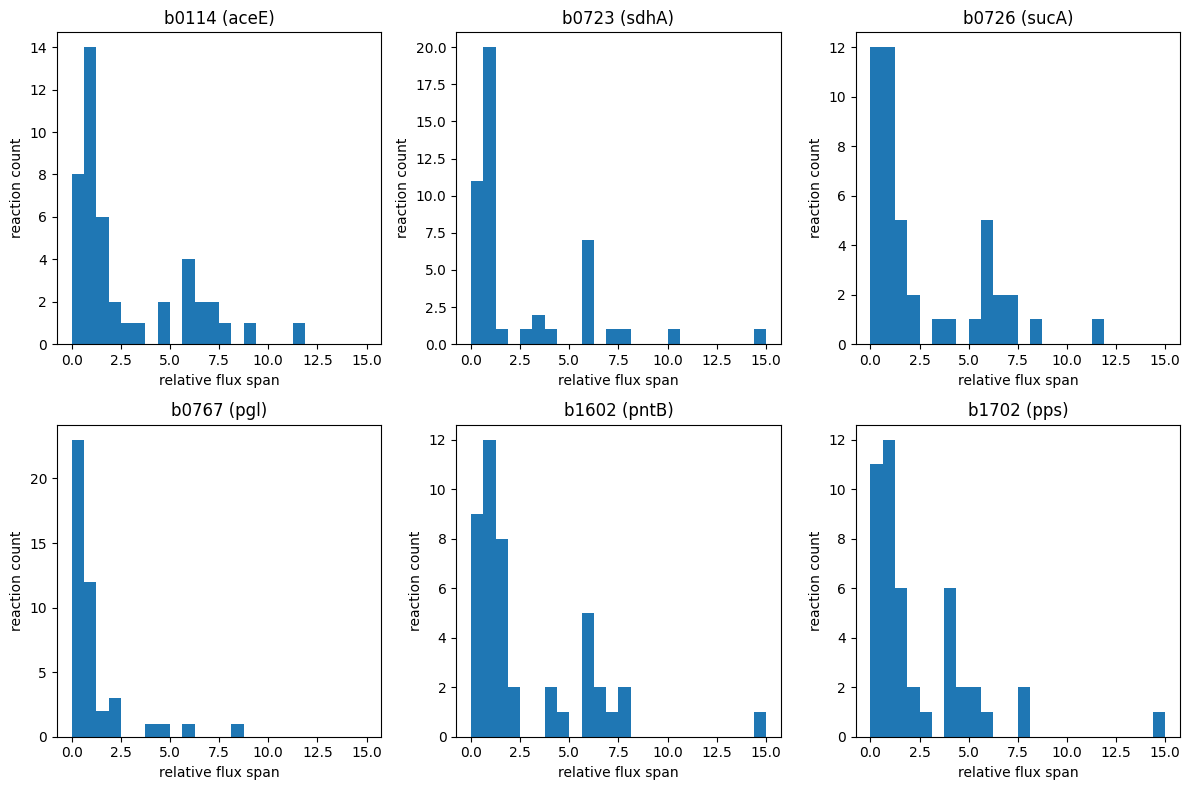

In [98]:
from cobra.flux_analysis import (
    flux_variability_analysis
)
model = load_model("textbook")
wt_solution = model.optimize()
wt_fluxes = wt_solution.fluxes
wt_fva = flux_variability_analysis(
    model,
    fraction_of_optimum=0.8
)
wt_fva["span"] = (
    wt_fva["maximum"]
    - wt_fva["minimum"]

)
genes_to_test = {
    "b0114": "aceE",
    "b0723": "sdhA",
    "b0726": "sucA",
    "b0767": "pgl",
    "b1602": "pntB",
    "b1702": "pps"
}
fig, axes = plt.subplots(
    2, 3,
    figsize=(12,8)
)
axes = axes.flatten()

for idx, (gene_id, gene_name) in enumerate(
    genes_to_test.items()
):
    with model:
        model.genes.get_by_id(
            gene_id
        ).knock_out()
        fva = flux_variability_analysis(
            model,
            fraction_of_optimum=0.8
        )
        spans = []
        for rxn in model.reactions:
            wt_flux = wt_fluxes[rxn.id]
            if abs(wt_flux) < 1e-4:
                continue
            span = (
                fva.loc[rxn.id, "maximum"]
                -
                fva.loc[rxn.id, "minimum"]
            )
            relative_span = abs(span / wt_flux)
            if relative_span > 15:
                
                continue
                
            spans.append(relative_span)

        ax = axes[idx]
        bins = np.linspace(0,15,25)
        ax.hist(
            spans,
            bins=bins
        )
        ax.set_title(
            f"{gene_id} ({gene_name})"
        )
        ax.set_xlabel(
            "relative flux span"
        )
        ax.set_ylabel(
            "reaction count")
        
plt.tight_layout()
plt.show()